# DAG examples — from scratch vs. from manifest

Worked examples for `jobs.py`/`dag.py`, following the training pipeline in
`job-spec.md`'s appendix: `DownloadSource` → `TrainTokenizer` → `TokenizeSource`
→ `BuildSplit` → `Pretrain` → `SFT`.

Two ways to build the same DAG:

- **from scratch** — construct every job bottom-up, passing each finished job
  straight into the next one's dependency slots.
- **from a manifest** — point a slot at an already-saved manifest path instead;
  `Job.from_manifest` loads it as a frozen leaf and *always* re-validates it
  (parameters re-checked against the pydantic model, declared outputs checked
  to exist on disk) rather than trusting it blindly.

Both land on the identical job `id` for anything built the same way, so a
notebook session can pick a pipeline up from wherever it left off instead of
restating it.

In [42]:
import json
import shutil
from pathlib import Path

from jobs import (
    DownloadSource, TrainTokenizer, TokenizeSource, BuildSplit, Pretrain, SFT,
    Job, JobError,
)
import dag

ROOT = Path("example_data")
# shutil.rmtree(ROOT, ignore_errors=True)   # re-runnable from a clean slate
# ROOT.mkdir()

RUN_ID = "gpt2-small-v1"

## 1. Build the DAG from scratch

`Job(parameters: dict, run_id: str, root=ROOT, **dependencies)` — every
dependency kwarg is a **list**, always, even a single one. This mirrors
job-spec.md's own appendix example almost verbatim.

In [43]:
VOCAB_SIZE = 64
TRAIN_SET = ["odyssey", "mobydick"]
VALID_SET = ["montecristo", "romeojuliet"]
TOKEN_SET = ["odyssey", "mobydick"]


def src(name):
    return DownloadSource(
        {"source_uid": name, "url": f"https://example.org/{name}.txt",
         "type": "text", "config": {"normalizer": "lowercase"}},
        RUN_ID, root=ROOT,
    )


sources = {name: src(name) for name in set(TRAIN_SET + VALID_SET)}

tokenizer = TrainTokenizer(
    {"tokenizer_uid": "llama-64", "vocab_size": VOCAB_SIZE, "kind": "bpe",
     "special_tokens": ["<|endoftext|>", "<|begin|>", "<|end|>"],
     "token_source_uids": TOKEN_SET},
    RUN_ID, root=ROOT,
    sources=[sources[name] for name in TOKEN_SET],
)

tokenized = {
    name: TokenizeSource(
        {"tokenizer_uid": "llama-64", "source_uid": name},
        RUN_ID, root=ROOT,
        source=[sources[name]], tokenizer=[tokenizer],
    )
    for name in set(TRAIN_SET + VALID_SET)
}

dataset = BuildSplit(
    {"train_source_uids": TRAIN_SET, "valid_source_uids": VALID_SET,
     "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT,
    tokenizer=[tokenizer],
    sources=[tokenized[name] for name in set(TRAIN_SET + VALID_SET)],
)

pretrain = Pretrain(
    {"run_id": RUN_ID, "model_config": {"n_layer": 2, "n_embd": 64},
     "training_config": {"lr": 3e-4, "epochs": 1}},
    RUN_ID, root=ROOT,
    dataset=[dataset],
)

sft = SFT(
    {"run_id": RUN_ID, "base_run_id": RUN_ID,
     "sft_training_config": {"lr": 1e-5, "epochs": 2}},
    RUN_ID, root=ROOT,
    base=[pretrain],
)

print("target id:", sft.id)

target id: c2001585ad3a


## 2. Topological order + status, before anything is materialized

`dag.status()` reads only what's on disk: `done` once every output exists,
`runnable` once every input exists (and it isn't done), else `blocked`. The two
`DownloadSource` jobs have no inputs, so they're immediately `runnable`;
everything downstream is `blocked` until its own inputs show up.

In [44]:
order

In [45]:
order = dag.topo_sort(sft)


def print_status(order):
    for j in order:
        print(f"{type(j).__name__:16s} {j.id}  {dag.status(j)}")


print_status(order)

DownloadSource   b01d134b4b9b  runnable
DownloadSource   dbcb09b964c9  runnable
TrainTokenizer   00bcd290b0ef  blocked
TokenizeSource   991377c1230b  blocked
DownloadSource   2f47feabd981  runnable
TokenizeSource   06a09a806858  blocked
TokenizeSource   71f5178174fe  blocked
DownloadSource   e5bf72092b66  runnable
TokenizeSource   b4aef00e1f9a  blocked
BuildSplit       b0c1192ff083  blocked
Pretrain         43f11496856b  blocked
SFT              c2001585ad3a  blocked


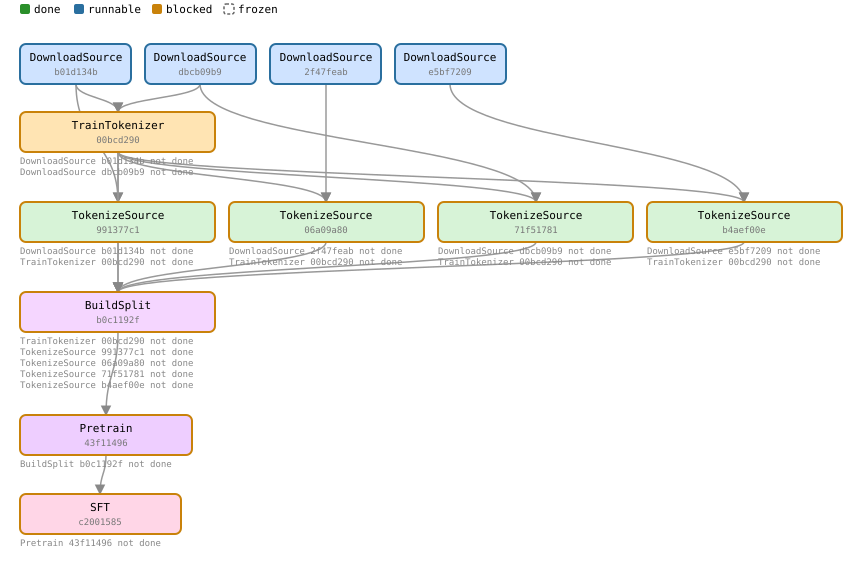

In [46]:
dag.dag_svg(sft)   # last line of the cell -- Jupyter renders the SVG directly

## 3. Materialize — walk status from blocked to done

job-spec.md deliberately stops at structure: it declares output *paths*, not
how to produce them. So here we just drop placeholder files at each job's
declared output paths ourselves, stage by stage, and watch `dag.status()`
react — no toy training loop needed to see the DAG behave correctly.

In [47]:
def materialize(job, output_name, filename="data.bin", content=b"placeholder"):
    """Write a placeholder file at job's declared output path for
    output_name -- into the glob directory for a "*" template, or the exact
    path otherwise."""
    fields = {**job.parameters.model_dump(mode="json"), "run_id": job.run_id, "id": job.id}
    pattern = job.outputs[output_name].format(**fields)
    path = (job.root / pattern[:-1] / filename) if pattern.endswith("*") else (job.root / pattern)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(content) if isinstance(content, bytes) else path.write_text(content)
    return path


for name, job in sources.items():
    materialize(job, "text", filename="part1.txt", content=f"text of {name}")
print("after materializing sources:")
print_status(order)

after materializing sources:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  runnable
TokenizeSource   991377c1230b  blocked
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  blocked
TokenizeSource   71f5178174fe  blocked
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  blocked
BuildSplit       b0c1192ff083  blocked
Pretrain         43f11496856b  blocked
SFT              c2001585ad3a  blocked


In [48]:
materialize(tokenizer, "tokenizer", filename="tokenizer.json", content="{}")
materialize(tokenizer, "config", filename="config.json", content="{}")
print("after materializing the tokenizer:")
print_status(order)

after materializing the tokenizer:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
TokenizeSource   991377c1230b  runnable
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  runnable
TokenizeSource   71f5178174fe  runnable
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  runnable
BuildSplit       b0c1192ff083  blocked
Pretrain         43f11496856b  blocked
SFT              c2001585ad3a  blocked


In [49]:
for job in tokenized.values():
    materialize(job, "bin", filename="shard0.bin")
print("after materializing tokenized sources:")
print_status(order)

after materializing tokenized sources:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
TokenizeSource   991377c1230b  done
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  done
TokenizeSource   71f5178174fe  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  done
BuildSplit       b0c1192ff083  runnable
Pretrain         43f11496856b  blocked
SFT              c2001585ad3a  blocked


In [50]:
materialize(dataset, "train", content=b"train")
materialize(dataset, "valid", content=b"valid")
print("after materializing the dataset split:")
print_status(order)

after materializing the dataset split:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
TokenizeSource   991377c1230b  done
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  done
TokenizeSource   71f5178174fe  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  done
BuildSplit       b0c1192ff083  done
Pretrain         43f11496856b  runnable
SFT              c2001585ad3a  blocked


In [51]:
materialize(pretrain, "checkpoints", filename="step1000.pt")
materialize(pretrain, "logs", filename="train.log", content="loss=...")
materialize(pretrain, "progress", content="{}")
materialize(sft, "checkpoints", filename="step500.pt")
materialize(sft, "logs", filename="train.log", content="loss=...")
materialize(sft, "progress", content="{}")
print("after materializing pretrain + sft:")
print_status(order)

after materializing pretrain + sft:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
TokenizeSource   991377c1230b  done
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  done
TokenizeSource   71f5178174fe  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  done
BuildSplit       b0c1192ff083  done
Pretrain         43f11496856b  done
SFT              c2001585ad3a  done


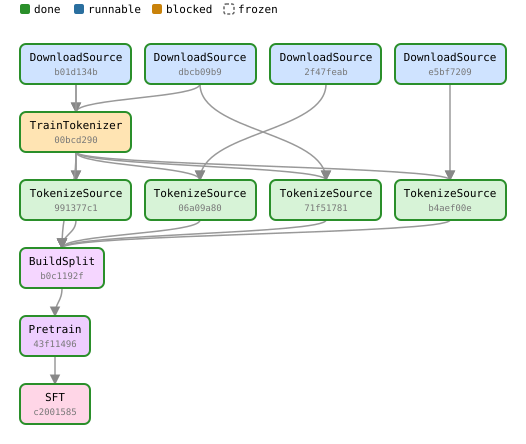

In [52]:
dag.dag_svg(sft)   # same DAG, now every box green

## 4. Save manifests

`job.save(path)` writes `job.to_manifest()` — the §5 schema, a **recursive
recipe** (each dependency nested inline as its own manifest), not a flat
graph. `job.to_manifest()` on its own just returns the dict without writing.

In [53]:
odyssey_manifest = sources["odyssey"].save(f"sources/odyssey/manifest.json")
tokenizer_manifest = tokenizer.save(f"tokenizers/llama-64/manifest.json")
for name, job in tokenized.items():
    job.save(f"tokenizers/llama-64/bin/{name}/manifest.json")
dataset_manifest = dataset.save(f"datasets/{dataset.id}/manifest.json")
pretrain_manifest = pretrain.save(f"runs/{RUN_ID}/pretrain/manifest.json")

print("saved:", tokenizer_manifest)
print(json.dumps(tokenizer.to_manifest(), indent=2)[:600], "...")

saved: tokenizers/llama-64/manifest.json
{
  "id": "00bcd290b0ef",
  "job_type": "TrainTokenizer",
  "parameters": {
    "tokenizer_uid": "llama-64",
    "vocab_size": 64,
    "kind": "bpe",
    "special_tokens": [
      "<|endoftext|>",
      "<|begin|>",
      "<|end|>"
    ],
    "token_source_uids": [
      "odyssey",
      "mobydick"
    ]
  },
  "dependencies": {
    "sources": [
      {
        "id": "b01d134b4b9b",
        "job_type": "DownloadSource",
        "parameters": {
          "source_uid": "odyssey",
          "url": "https://example.org/odyssey.txt",
          "type": "text",
          "config": {
            "norm ...


## 5. Pick up from a manifest instead of rebuilding

Point `TrainTokenizer`'s slot at the saved manifest path instead of the live
`tokenizer` object. `Job.from_manifest` loads it, re-validates its parameters,
and (by default) checks its declared outputs actually exist — then the DAG
stops there; its own upstream (`DownloadSource` for odyssey/mobydick) is not
rebuilt. The resulting `BuildSplit` still resolves to the exact same `id` as
the one built fully from scratch above.

In [54]:
tokenizer_frozen = Job.from_manifest(tokenizer_manifest, root=ROOT)
print("frozen:", tokenizer_frozen.frozen, " same id:", tokenizer_frozen.id == tokenizer.id)
print("dependencies rebuilt:", tokenizer_frozen.deps)   # {} -- not walked into

tokenized_frozen = {
    name: TokenizeSource.from_manifest(f"tokenizers/llama-64/bin/{name}/manifest.json", root=ROOT)
    for name in set(TRAIN_SET + VALID_SET)
}

dataset2 = BuildSplit(
    {"train_source_uids": TRAIN_SET, "valid_source_uids": VALID_SET,
     "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT,
    tokenizer=[tokenizer_frozen],
    sources=[tokenized_frozen[name] for name in set(TRAIN_SET + VALID_SET)],
)

print("dataset id (built from scratch):", dataset.id)
print("dataset id (built from manifest):", dataset2.id)
assert dataset2.id == dataset.id
print("OK: identical id, live deps vs. manifest-referenced deps")

frozen: True  same id: True
dependencies rebuilt: {}
dataset id (built from scratch): b0c1192ff083
dataset id (built from manifest): b0c1192ff083
OK: identical id, live deps vs. manifest-referenced deps


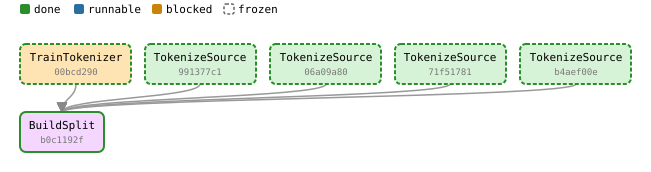

In [55]:
dag.dag_svg(dataset2)   # tokenizer + tokenized sources render dashed -- frozen, not walked into

## 6. Verification — a manifest is never just trusted

Two ways a saved manifest can go stale, and `from_manifest` catching both:
parameters that no longer validate, and a declared output that's gone
missing. `verify=False` is an escape hatch for the second check only —
parameter re-validation always runs.

In [56]:
# (a) tamper the parameters -- vocab_size becomes a string, fails the pydantic model.
# tokenizer_manifest is root-relative (what save()/from_manifest both expect),
# so touching the file directly needs ROOT joined back in.
tampered = json.loads((ROOT / tokenizer_manifest).read_text())
tampered["parameters"]["vocab_size"] = "not-an-int"
bad_params_relpath = Path(tokenizer_manifest).with_name("manifest_bad_params.json")
(ROOT / bad_params_relpath).write_text(json.dumps(tampered))

try:
    Job.from_manifest(bad_params_relpath, root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK: bad parameters rejected ->", e)

OK: bad parameters rejected -> example_data/tokenizers/llama-64/manifest_bad_params.json: parameters no longer validate -- 1 validation error for Parameters
vocab_size
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='not-an-int', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/int_parsing


In [57]:
# (b) tamper the outputs -- delete one of the tokenizer's declared output files
config_path = ROOT / "tokenizers/llama-64/config.json"
config_path.unlink()

try:
    Job.from_manifest(tokenizer_manifest, root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK: missing output rejected ->", e)

# verify=False bypasses the output-existence check (still re-validates parameters)
stale = Job.from_manifest(tokenizer_manifest, root=ROOT, verify=False)
print("OK: verify=False loads anyway ->", stale.frozen)

materialize(tokenizer, "config", filename="config.json", content="{}")   # restore

OK: missing output rejected -> example_data/tokenizers/llama-64/manifest.json: declared output(s) missing on disk -- ['tokenizers/llama-64/config.json']
OK: verify=False loads anyway -> True


PosixPath('example_data/tokenizers/llama-64/config.json')

## Tests

A few properties this design promises, checked directly.

In [58]:
# 1. Dependency slot names are a fixed, deterministic set per job type --
#    an unrecognized slot name is rejected outright, but there's no count to
#    satisfy for a recognized one: any number of jobs, including zero, is
#    accepted.
try:
    BuildSplit(
        {"train_source_uids": [], "valid_source_uids": [], "tokenizer_uid": "llama-64"},
        RUN_ID, root=ROOT, tokenizer=[tokenizer], not_a_slot=[],
    )
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK:", e)

empty_split = BuildSplit(
    {"train_source_uids": [], "valid_source_uids": [], "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT, tokenizer=[tokenizer], sources=[],
)
print("OK: an empty 'sources' list is accepted -- no cardinality to satisfy")

# 2. Anything that isn't a Job or a manifest path is rejected outright.
try:
    TokenizeSource(
        {"tokenizer_uid": "llama-64", "source_uid": "odyssey"},
        RUN_ID, root=ROOT, source=[{"not": "a job"}], tokenizer=[tokenizer],
    )
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK:", e)

# 3. A manifest path that doesn't exist fails loudly and immediately.
try:
    Job.from_manifest("no/such/manifest.json", root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK:", e)

# 4. status() is unaffected by which representation (live vs. frozen) a
#    dependency happens to be -- both resolve through the same output paths.
assert dag.status(dataset) == dag.status(dataset2) == "done"
print("OK: status agrees for live-built and manifest-built dataset")

# 5. Frozen nodes are terminal for both traversal and scheduling.
assert tokenizer_frozen.deps == {}
assert dag.scheduled(tokenizer_frozen, {}) is False
print("OK: a frozen node has no dependencies and is never scheduled")

print("\nALL TESTS PASSED")

OK: BuildSplit: unknown dependency slot(s) ['not_a_slot']
OK: an empty 'sources' list is accepted -- no cardinality to satisfy
OK: TokenizeSource: a dependency must be a Job or a manifest path, got {'not': 'a job'}
OK: manifest not found: example_data/no/such/manifest.json
OK: status agrees for live-built and manifest-built dataset
OK: a frozen node has no dependencies and is never scheduled

ALL TESTS PASSED
